In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:

# Set the style for the plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================
# 0. Load the data
# ==========================================
print("Loading data...")
# Main dataset
df_main = pd.read_csv('..\data\players_quarters_final.csv')

# Supplementary datasets (uncomment or ensure they are in the folder)
try:
    df_pass = pd.read_csv('..\data\player_appearance_pass.csv')
    df_press = pd.read_csv('..\data\player_appearance_behaviour_under_pressure.csv')
    df_run = pd.read_csv('..\data\player_appearance_run.csv')
    df_shot = pd.read_csv('..\data\player_appearance_shot_limited.csv')
    has_supp_data = True
except FileNotFoundError:
    print("Not all supplementary datasets were found. Charts requiring them will be skipped.")
    has_supp_data = False


Loading data...


<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Kinga\AppData\Local\Temp\ipykernel_12836\2723285889.py:10: SyntaxWarning: invalid escape sequence '\d'
  df_main = pd.read_csv('..\data\players_quarters_final.csv')
C:\Users\Kinga\AppData\Local\Temp\ipykernel_12836\2723285889.py:14: SyntaxWarning: invalid escape sequence '\d'
  df_pass = pd.read_csv('..\data\player_appearance_pass.csv')
C:\Users\Kinga\AppData\Local\Temp\ipykernel_12836\2723285889.py:15: SyntaxWarning: invalid escape sequence '\d'
  df_press = pd.read_csv('..\d

In [12]:

# ==========================================
# STATISTICAL TABLES
# ==========================================
print("\n--- GENERATING TABLES ---")

# Table 1: General descriptive statistics of continuous variables
cols_continuous = [c for c in df_main.columns if 'last15_' in c or 'cumul_' in c]
table_1 = df_main[cols_continuous].describe().T
print("\nTable 1: Descriptive statistics")
print(table_1[['mean','50%', 'std', 'min', 'max']])

# Table 2: Distribution of the target variable `scored_after` by checkpoint
table_2 = df_main.groupby('checkpoint')['scored_after'].value_counts(normalize=True).unstack() * 100
print("\nTable 2: Percentage distribution of target by checkpoint")
print(table_2)

# Table 3: Scorer effectiveness by position
table_3 = df_main.groupby('position')['scored_after'].mean().sort_values(ascending=False) * 100
print("\nTable 3: % chance of scoring by position")
print(table_3)

# Table 4: Physical intensity vs. pitch position
table_4 = df_main.groupby('position')[['last15_sprints', 'last15_distance']].mean()
print("\nTable 4: Average physical activity by position")
print(table_4)

# Table 5: Feature correlation matrix (last 15 min vs cumulative)
table_5 = df_main[['last15_distance', 'cumul_distance', 'last15_sprints', 'cumul_sprints']].corr()

# Table 6: Analysis of tactical formations
table_6 = df_main.groupby('formation').agg(
    count=('formation', 'count'),
    avg_shots=('last15_shots', 'mean')
).sort_values('count', ascending=False)

# Table 10: Physical profile of substitutes
table_10 = df_main.groupby('subbed')[['last15_distance', 'last15_sprints', 'last15_peak_speed']].mean()

if has_supp_data:
    # Table 7: Passing effectiveness in pitch zones
    table_7 = df_pass.groupby('stage')['accurate'].mean() * 100
    
    # Table 8: Opponent pressure outcomes
    table_8 = df_press.groupby(['stage', 'press_induced_outcome']).size().unstack(fill_value=0)
    
    # Table 9: Shot characteristics (Body part vs Technique)
    table_9 = pd.crosstab(df_shot['body_part'], df_shot['technique'])



--- GENERATING TABLES ---

Table 1: Descriptive statistics
                                mean      50%          std  min       max
last15_sprints              1.490820    1.000     1.421015  0.0      8.00
last15_hsr                  6.447504    6.000     3.836168  0.0     20.00
last15_distance           367.125017  107.195   978.769500  0.0   8028.31
last15_mean_max_speed       6.217783    6.638     1.760838  0.0     14.14
last15_peak_speed           7.278741    7.720     2.184753  0.0     14.14
last15_shots                0.167814    0.000     0.428815  0.0      4.00
last15_shots_on_target      0.060815    0.000     0.258629  0.0      3.00
last15_shots_under_press    0.131383    0.000     0.375668  0.0      3.00
last15_shots_top_third      0.162077    0.000     0.421593  0.0      4.00
cumul_sprints               4.171543    3.000     3.681721  0.0     22.00
cumul_hsr                  18.144291   16.000    12.880450  0.0     80.00
cumul_distance            969.208127  277.835  2701.


--- GENERATING GRAPHS ---


C:\Users\Kinga\AppData\Local\Temp\ipykernel_12836\1508075658.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_main, x='scored_after', palette='Set2')


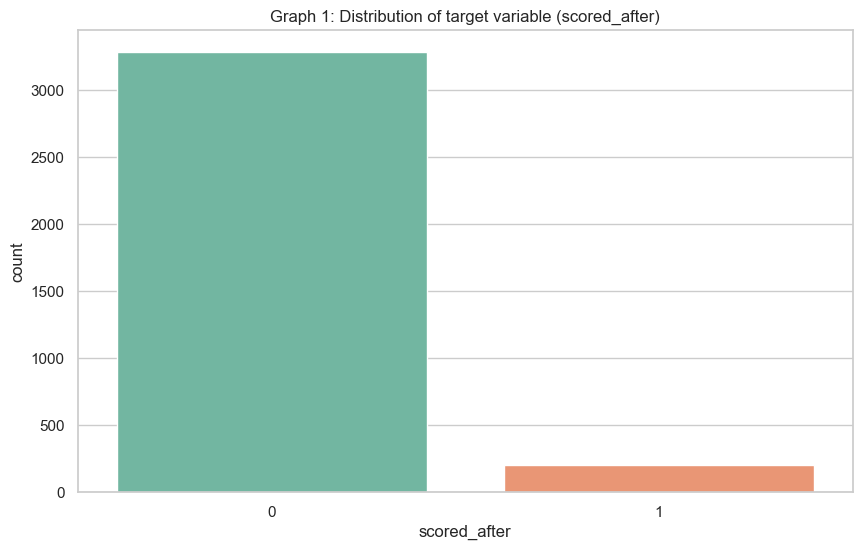

In [6]:

# ==========================================
# VISUALIZATIONS (GRAPHS)
# ==========================================
print("\n--- GENERATING GRAPHS ---")

# Graph 1: Target variable class balance bar chart
plt.figure()
sns.countplot(data=df_main, x='scored_after', palette='Set2')
plt.title('Graph 1: Distribution of target variable (scored_after)')
plt.show()


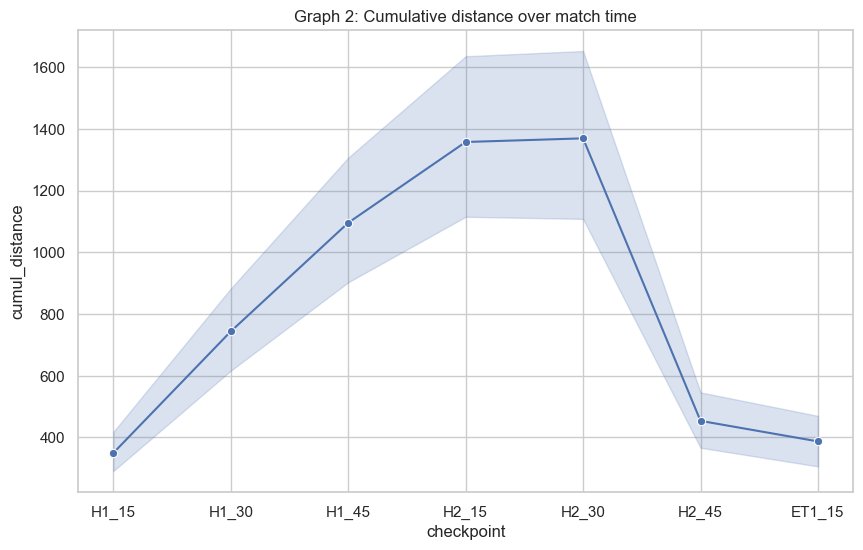

In [7]:

# Graph 2: Physical trend line chart
plt.figure()
sns.lineplot(data=df_main, x='checkpoint', y='cumul_distance', marker='o')
plt.title('Graph 2: Cumulative distance over match time')
plt.show()


The Substitution Effect: The dataset only logs players who are "actively on the pitch at the moment of the checkpoint". By the 90th minute (H2_45) and extra time (ET1_15), teams have usually made most of their substitutions. When a starter (who might have 1,500m of high-intensity running) leaves the pitch, they are removed from this average. The fresh substitute coming in starts their personal cumulative distance from zero. A sudden influx of fresh players with very low cumulative distance will drastically drag down the average for the whole group.

A Filtered Sample Size: The documentation notes that H2_45 and ET1_15 are only recorded "- for matches that reached extra time". At H2_45, you are no longer looking at all 31 matches; you are only looking at the small subset that ended in a draw after 90 minutes. This smaller sample size makes the average much more sensitive to the reset and substitution effects mentioned above.

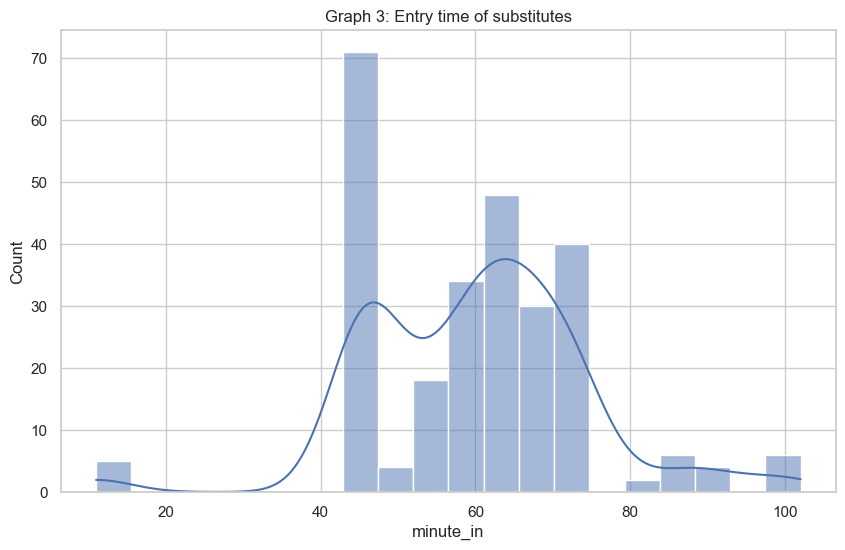

In [10]:
# Graph 3: Pitch entry time histogram for substitutes
plt.figure()
# We filter for minute_in > 1 to exclude starting players who were subbed off
sns.histplot(data=df_main[df_main['minute_in'] > 1], x='minute_in', bins=20, kde=True)
plt.title('Graph 3: Entry time of substitutes')
plt.show()


The dataset offers a highly granular, checkpoint-based snapshot of player activity across 31 football matches. By tracking physical exertion and technical actions—such as sprints, high-speed runs, and shots—in 15-minute intervals, the data reveals clear tactical rhythms, including distinct substitution windows at halftime and between the 60th and 75th minutes. However, analyzing this data requires navigating structural quirks; for instance, cumulative running metrics can artificially drop late in the game when tired starters are replaced by fresh substitutes whose counters begin at zero. Ultimately, carefully interpreting these temporal dynamics is crucial for building robust machine learning models to predict the dataset's highly imbalanced target variable: whether a specific player will score a non-own goal later in the match.

C:\Users\Kinga\AppData\Local\Temp\ipykernel_12836\829331978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='position', y='last15_distance', palette='Pastel1')


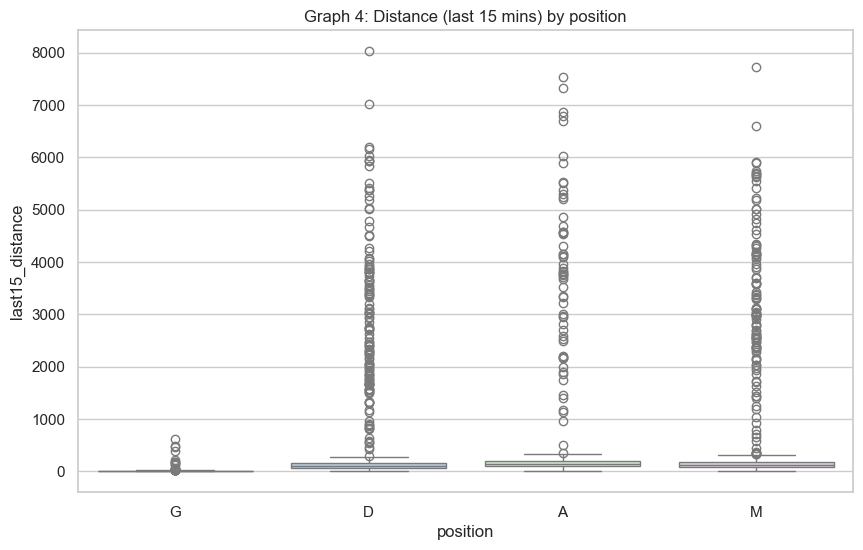

In [9]:

# Graph 4: Distance boxplot by position
plt.figure()
sns.boxplot(data=df_main, x='position', y='last15_distance', palette='Pastel1')
plt.title('Graph 4: Distance (last 15 mins) by position')
plt.show()

# Graph 5: Statistics profile by position (Bar subplots instead of complex radar for clarity)
radar_data = df_main

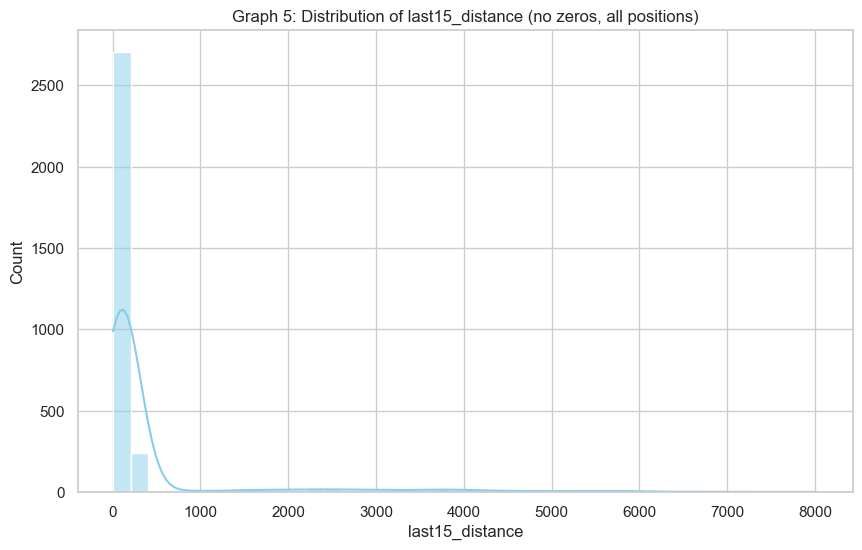

In [19]:
# Graph 5: Histogram of last15_distance (excluding zeros, all positions combined)
plt.figure()
filtered = df_main[df_main['last15_distance'] > 00]
sns.histplot(filtered['last15_distance'], kde=True, bins=40, color='skyblue')
plt.title('Graph 5: Distribution of last15_distance (no zeros, all positions)')
plt.xlabel('last15_distance')
plt.ylabel('Count')
plt.show()

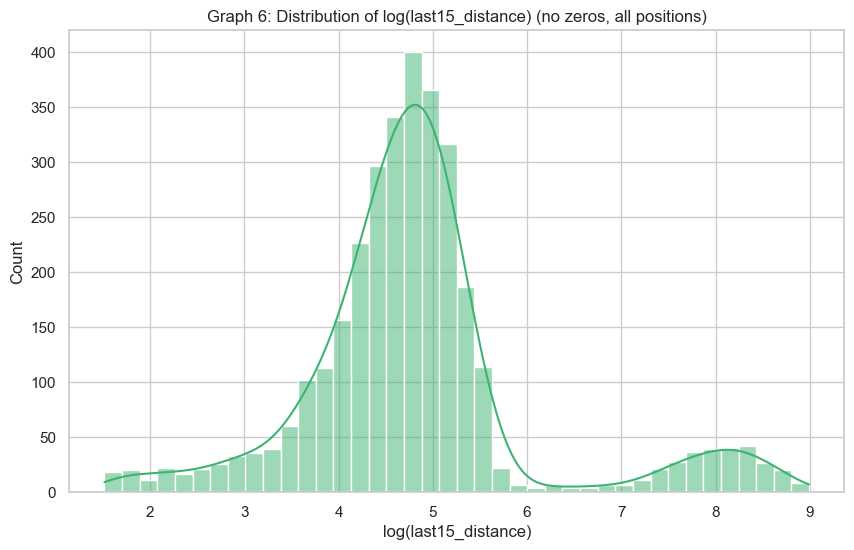

In [21]:
# Graph 6: Histogram of log(last15_distance) (excluding zeros, all positions combined)
plt.figure()
filtered = df_main[df_main['last15_distance'] > 0]
log_distance = np.log(filtered['last15_distance'])
sns.histplot(log_distance, kde=True, bins=40, color='mediumseagreen')
plt.title('Graph 6: Distribution of log(last15_distance) (no zeros, all positions)')
plt.xlabel('log(last15_distance)')
plt.ylabel('Count')
plt.show()

In [24]:
# Ile osób ma last15_distance > 5500?
count_over_5500 = (df_main['last15_distance'] > 5500).sum()
print(f'Liczba osób z last15_distance > 5500: {count_over_5500}')

Liczba osób z last15_distance > 5500: 29


In [25]:
# ==========================================
# STATISTICAL TABLES: PLAYER APPEARANCE RUN
# ==========================================
if has_supp_data and 'df_run' in locals():
    print("\n--- GENERATING TABLES FOR RUN DATA ---")

    # Table 11: General descriptive statistics of continuous run variables
    cols_run_continuous = ['distance', 'min_speed', 'max_speed']
    table_11 = df_run[cols_run_continuous].describe().T
    print("\nTable 11: Descriptive statistics of runs")
    print(table_11[['mean', '50%', 'std', 'min', 'max']])

    # Table 12: Distribution of run types (hsr vs sprint)
    table_12 = df_run['run_type'].value_counts(normalize=True) * 100
    print("\nTable 12: Percentage distribution of run types")
    print(table_12)

    # Table 13: Average speed and distance by run type
    # This validates that 'sprints' are indeed faster and potentially shorter/longer than 'hsr'
    table_13 = df_run.groupby('run_type')[['distance', 'min_speed', 'max_speed']].mean()
    print("\nTable 13: Average speed and distance by run type")
    print(table_13)

    # Table 14: Run volume by match period and type
    # Useful for spotting physical drop-offs in the second half or extra time
    table_14 = pd.crosstab(df_run['period'], df_run['run_type'])
    print("\nTable 14: Number of runs by match period and run type")
    print(table_14)

    # Table 15: Run intensity across pitch zones
    # Answers: Do players sprint faster in the attacking third vs defensive third?
    table_15 = df_run.groupby('stage')[['distance', 'max_speed']].mean()
    print("\nTable 15: Average run distance and max speed by pitch zone")
    print(table_15)

    # Table 16: Runs per possession sequence (Top 5 most intense possessions)
    # Shows how many runs occur during a single phase of play
    table_16 = df_run.groupby('possession').size().sort_values(ascending=False).head(5)
    print("\nTable 16: Top 5 possession sequences with the highest volume of runs")
    print(table_16)


--- GENERATING TABLES FOR RUN DATA ---

Table 11: Descriptive statistics of runs
                mean        50%         std       min       max
distance   47.927390  12.074841  121.727855  2.892288  1694.008
min_speed   5.351574   5.510000    0.895170  0.290000     7.280
max_speed   6.717121   6.720000    0.798054  5.440000    14.140

Table 12: Percentage distribution of run types
run_type
hsr       80.884069
sprint    19.115931
Name: proportion, dtype: float64

Table 13: Average speed and distance by run type
           distance  min_speed  max_speed
run_type                                 
hsr       43.165991   5.073733   6.438401
sprint    68.074003   6.527184   7.896452

Table 14: Number of runs by match period and run type
run_type        hsr  sprint
period                     
extra_time_1    252      43
extra_time_2    221      53
half_1        13879    3166
half_2        14065    3454

Table 15: Average run distance and max speed by pitch zone
         distance  max_speed
st

In [26]:
    # --- LaTeX export for all tables ---
    print("\nTable 11 (LaTeX):")
    print(table_11[['mean', '50%', 'std', 'min', 'max']].to_latex())
    print("\nTable 12 (LaTeX):")
    print(table_12.to_latex())
    print("\nTable 13 (LaTeX):")
    print(table_13.to_latex())
    print("\nTable 14 (LaTeX):")
    print(table_14.to_latex())
    print("\nTable 15 (LaTeX):")
    print(table_15.to_latex())
    print("\nTable 16 (LaTeX):")
    print(table_16.to_latex())


Table 11 (LaTeX):
\begin{tabular}{lrrrrr}
\toprule
 & mean & 50% & std & min & max \\
\midrule
distance & 47.927390 & 12.074841 & 121.727855 & 2.892288 & 1694.008000 \\
min_speed & 5.351574 & 5.510000 & 0.895170 & 0.290000 & 7.280000 \\
max_speed & 6.717121 & 6.720000 & 0.798054 & 5.440000 & 14.140000 \\
\bottomrule
\end{tabular}


Table 12 (LaTeX):
\begin{tabular}{lr}
\toprule
 & proportion \\
run_type &  \\
\midrule
hsr & 80.884069 \\
sprint & 19.115931 \\
\bottomrule
\end{tabular}


Table 13 (LaTeX):
\begin{tabular}{lrrr}
\toprule
 & distance & min_speed & max_speed \\
run_type &  &  &  \\
\midrule
hsr & 43.165991 & 5.073733 & 6.438401 \\
sprint & 68.074003 & 6.527184 & 7.896452 \\
\bottomrule
\end{tabular}


Table 14 (LaTeX):
\begin{tabular}{lrr}
\toprule
run_type & hsr & sprint \\
period &  &  \\
\midrule
extra_time_1 & 252 & 43 \\
extra_time_2 & 221 & 53 \\
half_1 & 13879 & 3166 \\
half_2 & 14065 & 3454 \\
\bottomrule
\end{tabular}


Table 15 (LaTeX):
\begin{tabular}{lrr}
\topru

In [23]:
import pandas as pd
import os

# Dictionary containing the names of all files from the WEC 2026 documentation
csv_files = {
    'Main Dataset (Quarters)': '..\data\players_quarters_final.csv',
    'Events - Passes': '..\data\player_appearance_pass.csv',
    'Events - Under Pressure': '..\data\player_appearance_behaviour_under_pressure.csv',
    'Events - Runs and Sprints': '..\data\player_appearance_run.csv',
    'Events - Shots': '..\data\player_appearance_shot_limited.csv'
}

print("GENERATING STATISTICAL TABLES FOR ALL DATASETS...\n")

for name, file_name in csv_files.items():
    print(f"{'='*60}")
    print(f"Table for: {name}")
    print(f"File: {file_name}")
    print(f"{'='*60}")
    
    # Check if the file exists in the directory
    if not os.path.exists(file_name):
        print(f"[WARNING] File not found: {file_name}. Skipping.\n")
        continue
        
    # Load the data
    df = pd.read_csv(file_name)
    
    # Select only numeric columns (int, float)
    numeric_cols = df.select_dtypes(include=['number']).columns
    
    # Filter out artificial identifiers so the statistics make sense
    cols_to_keep = [
        c for c in numeric_cols 
        if not c.endswith('_id') and c != 'id' and c != 'possession'
    ]
    
    if not cols_to_keep:
        print("No suitable continuous/numeric columns for statistical analysis found.\n")
        continue
        
    # Calculate statistics: count, mean, std, min, 25%, 50%, 75%, max
    stats = df[cols_to_keep].describe().T
    
    # Select only the requested metrics and rename '50%' to 'median'
    final_table = stats[['mean', '50%', 'std', 'min', 'max']].rename(columns={'50%': 'median'})
    
    # Round the values for better readability (optional)
    final_table = final_table.round(3)
    
    print(final_table.to_string())
    print("\n")


<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:9: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Kinga\AppData\Local\Temp\ipykernel_12836\204402995.py:6: SyntaxWarning: invalid escape sequence '\d'
  'Main Dataset (Quarters)': '..\data\players_quarters_final.csv',
C:\Users\Kinga\AppData\Local\Temp\ipykernel_12836\204402995.py:7: SyntaxWarning: invalid escape sequence '\d'
  'Events - Passes': '..\data\player_appearance_pass.csv',
C:\Users\Kinga\AppData\Local\Temp\ipykernel_12836\204402995.py:8: SyntaxWarning: invalid escape sequence '\d'
  'Events - Under Pressure': '..\data\play

GENERATING STATISTICAL TABLES FOR ALL DATASETS...

Table for: Main Dataset (Quarters)
File: ..\data\players_quarters_final.csv
                             mean   median       std   min       max
checkpoint_min             27.074   30.000    11.344  15.0     45.00
minute_in                   5.542    1.000    16.228   1.0    102.00
minute_out                 85.528   90.000    13.867  21.0    120.00
jersey_number              10.139    9.000     6.515   1.0     23.00
last15_sprints              1.491    1.000     1.421   0.0      8.00
last15_hsr                  6.448    6.000     3.836   0.0     20.00
last15_distance           367.125  107.195   978.770   0.0   8028.31
last15_mean_max_speed       6.218    6.638     1.761   0.0     14.14
last15_peak_speed           7.279    7.720     2.185   0.0     14.14
last15_shots                0.168    0.000     0.429   0.0      4.00
last15_shots_on_target      0.061    0.000     0.259   0.0      3.00
last15_shots_under_press    0.131    0.000   